# Смещённый A/B-тест: диагностика selection bias и оценка эффекта

## Executive summary

Интернет-магазин изменил кнопку оплаты и ожидает рост выручки на 8–10%. Прямое сравнение показывает **+11,8%**, но пилотная группа тратила больше ещё до запуска: в `month17` разрыв достиг **+42,9%**, а доля активных клиентов составляла 72,8% против 51,9%.

После корректировки по наблюдаемому предпериодному поведению оценки находятся около нуля. Однако назначение в пилот было неслучайным, а placebo-проверки обнаруживают смещение до эксперимента. Поэтому причинный эффект надёжно не идентифицирован: текущие данные **не подтверждают ожидаемые +8–10%**, и раскатка не рекомендуется. Нужен новый рандомизированный эксперимент.

## 1. Бизнес-задача, метрика и estimands

Тестовый период — `month18`, месяцы `month1`–`month17` относятся к предпериоду. `b_group=yes` означает назначение в пилот. Если фактическая экспозиция кнопки неизвестна, анализ оценивает эффект **назначения** (ITT).

Основная метрика — выручка в `month18` на eligible-клиента, в денежных единицах датасета.

- **ATE** — средний эффект будущего раската на всех 30 000 eligible-клиентов; основной бизнес-estimand.
- **ATT** — средний эффект для 3 000 клиентов, фактически выбранных в пилот; вторичный estimand.

После обнаружения неслучайного назначения это уже observational analysis. Причинная интерпретация скорректированных оценок требует условной обмениваемости по наблюдаемым признакам, positivity, consistency/SUTVA и отсутствия ненаблюдаемых конфаундеров. Эти предположения нельзя доказать по данным.

In [1]:
import os
os.environ.setdefault('LOKY_MAX_CPU_COUNT', '1')

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import NearestNeighbors

from statsmodels.formula.api import ols

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', 50)

RANDOM_STATE = 42
ALPHA = 0.05
EXPECTED_TEST_SHARE = 0.10

## 2. Данные и проверки качества

В строках находятся клиенты, в столбцах — пол, операционная система, выручка за 18 месяцев и группа пилота. Публичная лицензия исходного учебного набора не указана; персональных идентификаторов в файле нет.

In [2]:
DATA_PATH = Path('data/ab_test_data.xlsx')
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f'Не найден {DATA_PATH}. Запускайте ноутбук из корня репозитория.'
    )

df = pd.read_excel(DATA_PATH, index_col=0)
months = [f'month{i}' for i in range(1, 19)]
pre_months = months[:-1]
TEST_MONTH = 'month18'

required = {'gender', 'OS', 'b_group', *months}
assert required.issubset(df.columns), 'В данных отсутствуют обязательные столбцы'
assert df.index.is_unique, 'Индекс клиента должен быть уникальным'
assert df[list(months)].notna().all().all(), 'В месячных метриках есть пропуски'
assert (df[list(months)] >= 0).all().all(), 'Выручка не должна быть отрицательной'
assert set(df['b_group']) == {'yes', 'no'}, 'Неожиданные значения b_group'

quality = pd.Series({
    'строк': len(df),
    'столбцов': df.shape[1],
    'пропусков': int(df.isna().sum().sum()),
    'повторяющихся профилей без учёта ID': int(df.duplicated().sum()),
    'уникальных ID': int(df.index.nunique()),
})
display(quality.to_frame('значение'))
df.head(3)

,значение
строк,30000
столбцов,21
пропусков,0
повторяющихся профилей без учёта ID,1
уникальных ID,30000


,gender,OS,month1,month2,month3,month4,month5,month6,month7,month8,month9,month10,month11,month12,month13,month14,month15,month16,month17,month18,b_group
0,woman,Android,0.000000,0.000000,1260.801227,1245.777408,0.000000,0.000000,1381.093860,1237.133907,1114.715221,1110.443064,0.000000,0.000000,0.000000,0.000000,1362.797130,1555.238727,0.0,0.00000,no
1,man,Android,2142.521523,1821.295907,1832.895312,1646.448173,0.000000,2154.948644,1912.998501,1795.471291,1464.396056,0.000000,2253.871388,2526.126916,2861.138746,3068.924457,3384.232538,0.000000,0.0,0.00000,yes
2,man,iOS,2064.105816,0.000000,0.000000,1454.148004,1821.118092,1917.801237,2188.827425,0.000000,1687.245010,1605.922754,0.000000,0.000000,1672.408077,1403.642040,1094.256738,962.442222,0.0,1483.00722,no


In [3]:
df['treatment'] = (df['b_group'] == 'yes').astype(int)
df['activity16'] = (df['month16'] > 0).astype(int)
df['activity17'] = (df['month17'] > 0).astype(int)
df['pre_mean_1_15'] = df[[f'month{i}' for i in range(1, 16)]].mean(axis=1)
df['pre_active_rate_1_15'] = (
    df[[f'month{i}' for i in range(1, 16)]] > 0
).mean(axis=1)

T = df['treatment'].to_numpy()
Y = df[TEST_MONTH].to_numpy()
n, n_test = len(df), int(T.sum())

# SRM имеет смысл только при заранее известном плане 10/90.
srm = stats.binomtest(n_test, n=n, p=EXPECTED_TEST_SHARE)
print(f'Контроль: {n-n_test:,}; пилот: {n_test:,}; фактическая доля пилота: {n_test/n:.1%}')
print(f'SRM при плановой доле 10%: p-value = {srm.pvalue:.3f}')

Контроль: 27,000; пилот: 3,000; фактическая доля пилота: 10.0%
SRM при плановой доле 10%: p-value = 1.000


Ровно 3 000 из 30 000 клиентов находятся в пилоте. При условии, что плановая доля действительно была 10%, SRM не обнаруживается. Но правильное количество наблюдений **не доказывает рандомизацию** — необходимо проверить предпериодные признаки.

## 3. Диагностика назначения в пилот

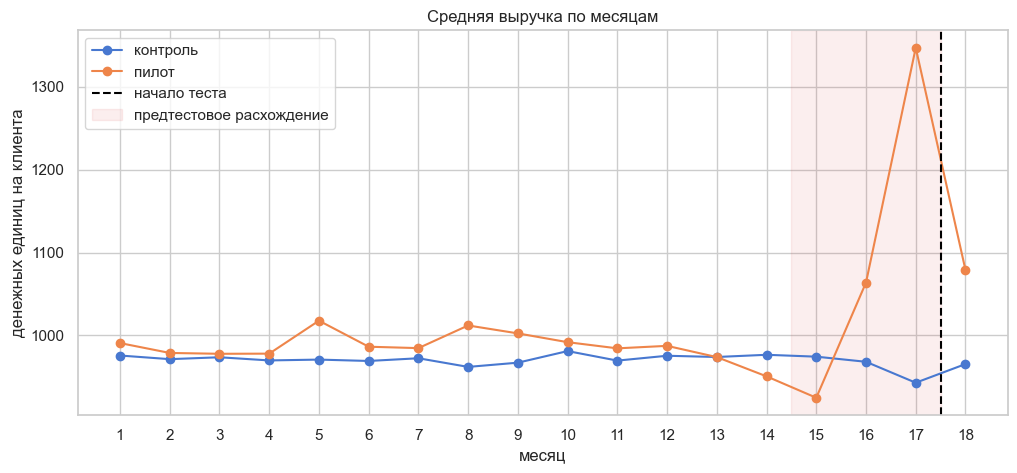

,контроль,пилот,разница,"разница, %"
month13,974.00,973.88,-0.12,-0.01
month14,976.66,950.63,-26.02,-2.66
month15,974.40,924.81,-49.59,-5.09
month16,968.21,1063.84,95.63,9.88
month17,942.95,1347.21,404.26,42.87
month18,965.45,1079.01,113.56,11.76


In [4]:
mean_by_month = df.groupby('b_group')[months].mean().T

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(1, 19), mean_by_month['no'], marker='o', label='контроль')
ax.plot(range(1, 19), mean_by_month['yes'], marker='o', label='пилот')
ax.axvline(17.5, color='black', ls='--', label='начало теста')
ax.axvspan(14.5, 17.5, color='tab:red', alpha=.08, label='предтестовое расхождение')
ax.set(title='Средняя выручка по месяцам', xlabel='месяц', ylabel='денежных единиц на клиента')
ax.set_xticks(range(1, 19))
ax.legend()
plt.show()

gaps = pd.DataFrame({
    'контроль': mean_by_month['no'],
    'пилот': mean_by_month['yes'],
})
gaps['разница'] = gaps['пилот'] - gaps['контроль']
gaps['разница, %'] = (gaps['пилот'] / gaps['контроль'] - 1) * 100
display(gaps.tail(6).round(2))

,"активны в month16, %","активны в month17, %"
b_group,,
контроль,53.2,51.9
пилот,57.3,72.8


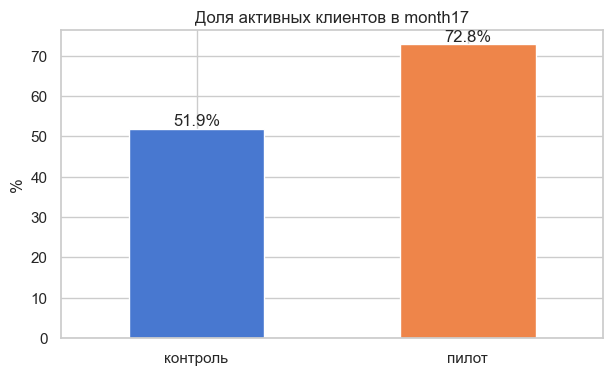

In [5]:
activity_summary = (
    df.groupby('b_group')[['activity16', 'activity17']]
      .mean()
      .rename(index={'no': 'контроль', 'yes': 'пилот'})
)
display((activity_summary * 100).round(1).rename(columns={
    'activity16': 'активны в month16, %',
    'activity17': 'активны в month17, %',
}))

fig, ax = plt.subplots(figsize=(7, 4))
(activity_summary['activity17'] * 100).plot(kind='bar', ax=ax, color=['C0', 'C1'])
ax.set(title='Доля активных клиентов в month17', xlabel='', ylabel='%')
ax.bar_label(ax.containers[0], fmt='%.1f%%')
plt.xticks(rotation=0)
plt.show()

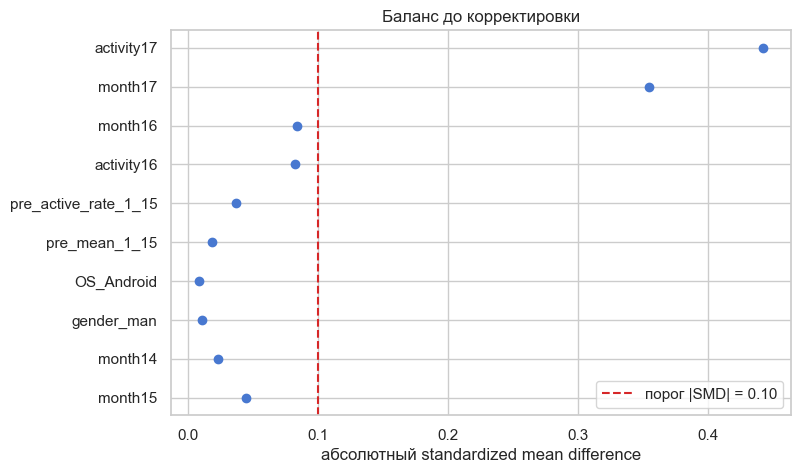

,SMD
month15,-0.044
month14,-0.023
gender_man,-0.010
OS_Android,0.008
pre_mean_1_15,0.018
pre_active_rate_1_15,0.037
activity16,0.082
month16,0.083
month17,0.355
activity17,0.442


In [6]:
def smd_unweighted(x, treatment):
    x = np.asarray(x, dtype=float)
    xt, xc = x[treatment == 1], x[treatment == 0]
    pooled = np.sqrt((xt.var(ddof=1) + xc.var(ddof=1)) / 2)
    return 0.0 if pooled == 0 else (xt.mean() - xc.mean()) / pooled

balance_features = pd.DataFrame({
    'gender_man': (df['gender'] == 'man').astype(int),
    'OS_Android': (df['OS'] == 'Android').astype(int),
    'month14': df['month14'],
    'month15': df['month15'],
    'month16': df['month16'],
    'month17': df['month17'],
    'activity16': df['activity16'],
    'activity17': df['activity17'],
    'pre_mean_1_15': df['pre_mean_1_15'],
    'pre_active_rate_1_15': df['pre_active_rate_1_15'],
})

raw_smd = balance_features.apply(lambda x: smd_unweighted(x, T)).sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(raw_smd.abs(), raw_smd.index)
ax.axvline(.1, color='tab:red', ls='--', label='порог |SMD| = 0.10')
ax.set(title='Баланс до корректировки', xlabel='абсолютный standardized mean difference', ylabel='')
ax.legend()
plt.show()

display(raw_smd.rename('SMD').to_frame().round(3))

Пол и ОС сбалансированы, однако поведение перед тестом — нет. Доля активных в `month17` составляет 72,8% в пилоте против 51,9% в контроле; SMD активности значительно превышает 0,10. Уже в `month15`–`month17` траектории расходятся. Следовательно, наивное сравнение не имеет причинной интерпретации.

## 4. Наивная оценка

In [7]:
def normal_result(estimate, se, denominator, alpha=ALPHA):
    q = stats.norm.ppf(1 - alpha/2)
    low, high = estimate - q*se, estimate + q*se
    pvalue = 2 * stats.norm.sf(abs(estimate / se))
    return {
        'estimate': estimate, 'se': se, 'low': low, 'high': high,
        'pvalue': pvalue, 'relative': estimate / denominator,
        'relative_low': low / denominator, 'relative_high': high / denominator,
        'denominator': denominator,
    }

yt, yc = Y[T == 1], Y[T == 0]
naive_est = yt.mean() - yc.mean()
naive_se = np.sqrt(yt.var(ddof=1)/len(yt) + yc.var(ddof=1)/len(yc))
naive = normal_result(naive_est, naive_se, yc.mean())

print(f"Наивная разница: {naive['estimate']:+.1f} ({naive['relative']:+.1%})")
print(f"95% ДИ: [{naive['low']:.1f}; {naive['high']:.1f}], p-value = {naive['pvalue']:.2e}")

Наивная разница: +113.6 (+11.8%)
95% ДИ: [69.9; 157.2], p-value = 3.34e-07


Наивная оценка почти совпадает с ожиданием менеджера, но смешивает возможный эффект кнопки с selection bias. Предтестовый разрыв в `month17` (+42,9%) намного больше наблюдаемого результата тестового месяца.

## 5. Постстратификация: прозрачное объяснение композиционного смещения

Постстратификация по активности в `month17` стандартизирует обе группы к одной и той же структуре целевой популяции. Это оценка ATE только при условии, что внутри страт не осталось конфаундинга. Дисперсия считается по фактическим размерам групп в каждой страте:

\[
\widehat{Var}(\hat\tau)=\sum_h W_h^2\left(\frac{s^2_{1h}}{n_{1h}}+\frac{s^2_{0h}}{n_{0h}}\right).
\]

In [8]:
target_weights = df['activity17'].value_counts(normalize=True).sort_index()
post_est = 0.0
post_var = 0.0
post_control_mean = 0.0
strata_rows = []

for stratum, weight in target_weights.items():
    t_values = df.loc[(df['treatment'] == 1) & (df['activity17'] == stratum), TEST_MONTH]
    c_values = df.loc[(df['treatment'] == 0) & (df['activity17'] == stratum), TEST_MONTH]
    diff = t_values.mean() - c_values.mean()
    post_est += weight * diff
    post_control_mean += weight * c_values.mean()
    post_var += weight**2 * (
        t_values.var(ddof=1)/len(t_values) + c_values.var(ddof=1)/len(c_values)
    )
    strata_rows.append({
        'activity17': stratum,
        'target_weight': weight,
        'n_test': len(t_values),
        'n_control': len(c_values),
        'mean_test': t_values.mean(),
        'mean_control': c_values.mean(),
        'difference': diff,
    })

post = normal_result(post_est, np.sqrt(post_var), post_control_mean)
display(pd.DataFrame(strata_rows).round(2))
print(f"Постстратифицированный ATE: {post['estimate']:+.1f} ({post['relative']:+.1%})")
print(f"95% ДИ: [{post['low']:.1f}; {post['high']:.1f}], p-value = {post['pvalue']:.3f}")

,activity17,target_weight,n_test,n_control,mean_test,mean_control,difference
0,0,0.46,816,12991,700.41,737.92,-37.51
1,1,0.54,2184,14009,1220.47,1176.45,44.02


Постстратифицированный ATE: +6.5 (+0.7%)
95% ДИ: [-36.8; 49.8], p-value = 0.769


После выравнивания долей активных наивные +11,8% сокращаются примерно до +0,7%. Это демонстрирует композиционную природу большей части разрыва, но одна бинарная страта не гарантирует устранение всего смещения.

## 6. Прозрачная регрессионная корректировка

In [9]:
ancova = ols(
    'month18 ~ treatment + month16 + month17 + activity16 + activity17 + C(gender) + C(OS)',
    data=df,
).fit(cov_type='HC3')

ols_adjusted = normal_result(
    ancova.params['treatment'], ancova.bse['treatment'], yc.mean()
)
print(f"OLS с HC3: {ols_adjusted['estimate']:+.1f} ({ols_adjusted['relative']:+.1%})")
print(f"95% ДИ: [{ols_adjusted['low']:.1f}; {ols_adjusted['high']:.1f}], "
      f"p-value = {ols_adjusted['pvalue']:.3f}")

OLS с HC3: +3.0 (+0.3%)
95% ДИ: [-34.8; 40.9], p-value = 0.876


Регрессия с робастными HC3-ошибками — понятный baseline, но её вывод зависит от правильной спецификации условного среднего. CUPED в нерандомизированных данных сам по себе не исправляет confounding, поэтому далее используется cross-fitting и doubly robust AIPW.

## 7. Cross-fitted AIPW: основной условный ATE

Используем все 17 предпериодных месячных значений, индикаторы активности, пол и ОС. В пятифолдном cross-fitting каждое наблюдение получает propensity и прогнозы потенциальных исходов от моделей, которые не обучались на этом наблюдении. Это устраняет in-sample leakage текущего CUPAC-подхода.

AIPW является doubly robust относительно моделей propensity и outcome, но **не защищает от ненаблюдаемого confounding**.

In [10]:
def make_feature_matrix(data, last_pre_month):
    used_months = [f'month{i}' for i in range(1, last_pre_month + 1)]
    features = data[used_months + ['gender', 'OS']].copy()
    for month in used_months:
        features[f'active_{month}'] = (features[month] > 0).astype(int)
    return pd.get_dummies(
        features, columns=['gender', 'OS'], drop_first=True, dtype=float
    )


def crossfit_nuisance(X, outcome, treatment, seed=RANDOM_STATE, max_iter=120):
    e_hat = np.zeros(len(outcome))
    m0_hat = np.zeros(len(outcome))
    m1_hat = np.zeros(len(outcome))
    splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    for fold, (train, valid) in enumerate(splitter.split(X, treatment)):
        params = dict(
            max_iter=max_iter,
            max_depth=3,
            learning_rate=.05,
            l2_regularization=2.0,
            random_state=seed + fold,
        )
        propensity = HistGradientBoostingClassifier(**params)
        outcome_0 = HistGradientBoostingRegressor(**params)
        outcome_1 = HistGradientBoostingRegressor(**params)

        propensity.fit(X.iloc[train], treatment[train])
        outcome_0.fit(
            X.iloc[train][treatment[train] == 0],
            outcome[train][treatment[train] == 0],
        )
        outcome_1.fit(
            X.iloc[train][treatment[train] == 1],
            outcome[train][treatment[train] == 1],
        )

        e_hat[valid] = propensity.predict_proba(X.iloc[valid])[:, 1]
        m0_hat[valid] = outcome_0.predict(X.iloc[valid])
        m1_hat[valid] = outcome_1.predict(X.iloc[valid])

    return e_hat, m0_hat, m1_hat


def aipw_ate_att(outcome, treatment, e_hat, m0_hat, m1_hat, clip=(.02, .98)):
    e = np.clip(e_hat, *clip)

    psi_ate = (
        m1_hat - m0_hat
        + treatment * (outcome - m1_hat) / e
        - (1-treatment) * (outcome - m0_hat) / (1-e)
    )
    ate = psi_ate.mean()
    ate_se = psi_ate.std(ddof=1) / np.sqrt(len(outcome))

    phi0 = m0_hat + (1-treatment) * (outcome-m0_hat) / (1-e)
    mu0_ate = phi0.mean()

    p_t = treatment.mean()
    g_att = (
        treatment * (outcome-m0_hat)
        - (1-treatment) * e/(1-e) * (outcome-m0_hat)
    )
    att = g_att.mean() / p_t
    influence_att = (g_att - att*treatment) / p_t
    att_se = influence_att.std(ddof=1) / np.sqrt(len(outcome))
    mu0_att = outcome[treatment == 1].mean() - att

    return (
        normal_result(ate, ate_se, mu0_ate),
        normal_result(att, att_se, mu0_att),
        e,
    )

In [11]:
X = make_feature_matrix(df, last_pre_month=17)
e_hat, m0_hat, m1_hat = crossfit_nuisance(X, Y, T)
aipw_ate, aipw_att, e = aipw_ate_att(Y, T, e_hat, m0_hat, m1_hat)

print(f"AIPW ATE: {aipw_ate['estimate']:+.1f} ({aipw_ate['relative']:+.1%})")
print(f"95% ДИ: [{aipw_ate['low']:.1f}; {aipw_ate['high']:.1f}], "
      f"p-value = {aipw_ate['pvalue']:.3f}")
print(f"AIPW ATT: {aipw_att['estimate']:+.1f} ({aipw_att['relative']:+.1%})")
print(f"95% ДИ: [{aipw_att['low']:.1f}; {aipw_att['high']:.1f}], "
      f"p-value = {aipw_att['pvalue']:.3f}")

AIPW ATE: +1.7 (+0.2%)
95% ДИ: [-38.2; 41.6], p-value = 0.934
AIPW ATT: +12.2 (+1.1%)
95% ДИ: [-25.1; 49.4], p-value = 0.521


### 7.1 Overlap и баланс после propensity weighting

OOF ROC-AUC propensity-модели: 0.604
Квантили propensity:


,контроль,пилот
min,0.0215,0.0322
1%,0.0464,0.0508
5%,0.0575,0.0605
50%,0.0999,0.1268
95%,0.1451,0.1470
99%,0.1565,0.1608
max,0.2075,0.1889


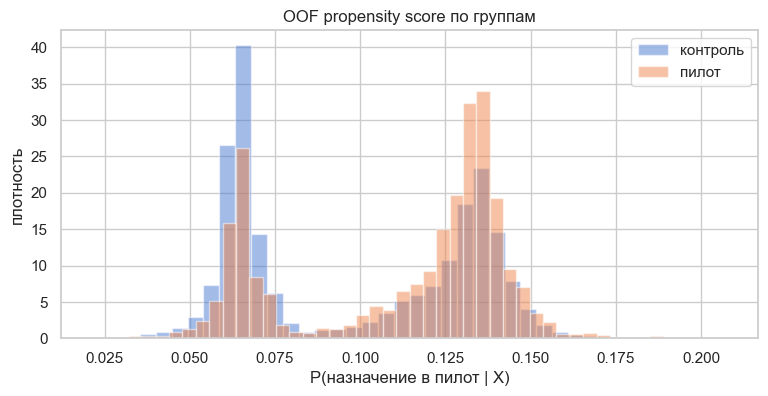

Доля propensity, затронутая clipping [0.02; 0.98]: 0.00%


In [12]:
print(f'OOF ROC-AUC propensity-модели: {roc_auc_score(T, e_hat):.3f}')
print('Квантили propensity:')
display(pd.DataFrame({
    'контроль': np.quantile(e_hat[T == 0], [0, .01, .05, .5, .95, .99, 1]),
    'пилот': np.quantile(e_hat[T == 1], [0, .01, .05, .5, .95, .99, 1]),
}, index=['min', '1%', '5%', '50%', '95%', '99%', 'max']).round(4))

fig, ax = plt.subplots(figsize=(9, 4))
for value, label, color in [(0, 'контроль', 'C0'), (1, 'пилот', 'C1')]:
    ax.hist(e_hat[T == value], bins=40, density=True, alpha=.5, label=label, color=color)
ax.set(title='OOF propensity score по группам', xlabel='P(назначение в пилот | X)', ylabel='плотность')
ax.legend()
plt.show()

print(f'Доля propensity, затронутая clipping [0.02; 0.98]: '
      f'{((e_hat < .02) | (e_hat > .98)).mean():.2%}')

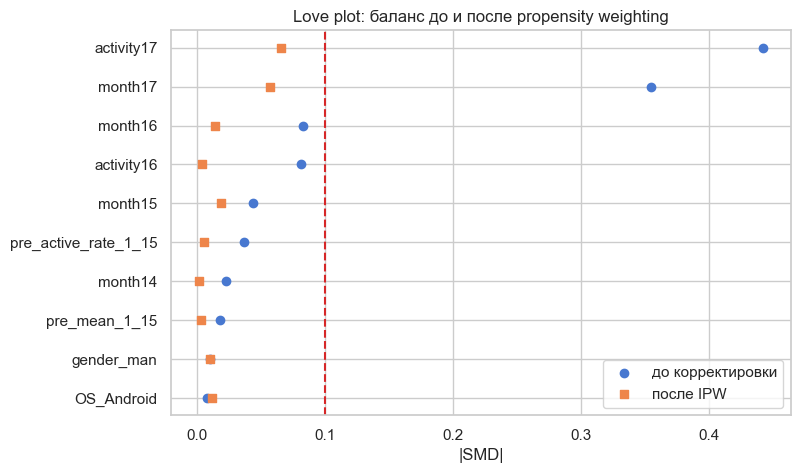

Максимальный |SMD|: до 0.442, после 0.066
ESS пилота: 2621 из 3000
ESS контроля: 26960 из 27000


In [13]:
def weighted_smd(x, treatment, weights):
    x = np.asarray(x, dtype=float)
    result = []
    for group in (1, 0):
        mask = treatment == group
        w = weights[mask]
        values = x[mask]
        mean = np.average(values, weights=w)
        var = np.average((values-mean)**2, weights=w)
        result.append((mean, var))
    pooled = np.sqrt((result[0][1] + result[1][1]) / 2)
    return 0.0 if pooled == 0 else (result[0][0] - result[1][0]) / pooled


ate_weights = np.where(T == 1, 1/e, 1/(1-e))
weighted_balance = balance_features.apply(
    lambda x: weighted_smd(x, T, ate_weights)
)

balance_plot = pd.DataFrame({
    'до корректировки': raw_smd.abs(),
    'после IPW': weighted_balance.abs(),
}).sort_values('до корректировки')

fig, ax = plt.subplots(figsize=(8, 5))
for name, marker in [('до корректировки', 'o'), ('после IPW', 's')]:
    ax.scatter(balance_plot[name], balance_plot.index, label=name, marker=marker)
ax.axvline(.1, color='tab:red', ls='--')
ax.set(title='Love plot: баланс до и после propensity weighting', xlabel='|SMD|', ylabel='')
ax.legend()
plt.show()

def effective_sample_size(weights):
    return weights.sum()**2 / np.square(weights).sum()

print(f"Максимальный |SMD|: до {balance_plot['до корректировки'].max():.3f}, "
      f"после {balance_plot['после IPW'].max():.3f}")
print(f'ESS пилота: {effective_sample_size(ate_weights[T == 1]):.0f} из {(T == 1).sum()}')
print(f'ESS контроля: {effective_sample_size(ate_weights[T == 0]):.0f} из {(T == 0).sum()}')

Распределения propensity перекрываются, экстремальных весов нет, а баланс наблюдаемых признаков после weighting улучшается. Это поддерживает positivity по измеренным признакам, но ничего не говорит о ненаблюдаемых факторах назначения.

## 8. Matching без возвращения: ATT

Для вторичного ATT выполняется 1:1 propensity-score matching **без возвращения**, отдельно внутри четырёх комбинаций активности `activity16 × activity17`. Caliper равен 0,2 стандартного отклонения logit propensity. После матчинга проверяются количество пар, расстояния и SMD. Уникальность контролей позволяет использовать анализ разностей внутри независимых пар как прозрачное приближение.

In [14]:
propensity_for_matching = HistGradientBoostingClassifier(
    max_iter=120,
    max_depth=3,
    learning_rate=.05,
    l2_regularization=2.0,
    random_state=RANDOM_STATE,
).fit(X, T)

e_match = np.clip(propensity_for_matching.predict_proba(X)[:, 1], .001, .999)
logit_propensity = np.log(e_match / (1-e_match))
caliper = .2 * logit_propensity.std()

t_positions = np.flatnonzero(T == 1)
c_positions = np.flatnonzero(T == 0)
picked_control = np.full(len(t_positions), -1, dtype=int)
match_distance = np.full(len(t_positions), np.nan)

activity16 = df['activity16'].to_numpy()
activity17 = df['activity17'].to_numpy()

for a16 in (0, 1):
    for a17 in (0, 1):
        t_local = np.flatnonzero(
            (activity16[t_positions] == a16) & (activity17[t_positions] == a17)
        )
        c_local = np.flatnonzero(
            (activity16[c_positions] == a16) & (activity17[c_positions] == a17)
        )
        neighbors = NearestNeighbors(
            n_neighbors=min(250, len(c_local))
        ).fit(logit_propensity[c_positions[c_local]].reshape(-1, 1))
        distances, indices = neighbors.kneighbors(
            logit_propensity[t_positions[t_local]].reshape(-1, 1)
        )

        used = set()
        for row in np.argsort(distances[:, 0])[::-1]:
            for distance, neighbor in zip(distances[row], indices[row]):
                control_local_position = int(c_local[neighbor])
                if control_local_position not in used and distance <= caliper:
                    picked_control[t_local[row]] = control_local_position
                    match_distance[t_local[row]] = distance
                    used.add(control_local_position)
                    break

matched = picked_control >= 0
matched_t_positions = t_positions[matched]
matched_c_positions = c_positions[picked_control[matched]]
assert len(np.unique(matched_c_positions)) == len(matched_c_positions)

pair_diff = Y[matched_t_positions] - Y[matched_c_positions]
match_est = pair_diff.mean()
match_se = pair_diff.std(ddof=1) / np.sqrt(len(pair_diff))
matching_att = normal_result(match_est, match_se, Y[matched_c_positions].mean())

print(f'Сформировано {matched.sum()} уникальных пар из {len(t_positions)} клиентов пилота')
print(f'Caliper: {caliper:.4f}; максимальная дистанция: {np.nanmax(match_distance):.4f}')
print(f"Matching ATT: {matching_att['estimate']:+.1f} ({matching_att['relative']:+.1%})")
print(f"95% ДИ: [{matching_att['low']:.1f}; {matching_att['high']:.1f}], "
      f"p-value = {matching_att['pvalue']:.3f}")

Сформировано 2999 уникальных пар из 3000 клиентов пилота
Caliper: 0.0887; максимальная дистанция: 0.0764
Matching ATT: +3.2 (+0.3%)
95% ДИ: [-51.2; 57.5], p-value = 0.909


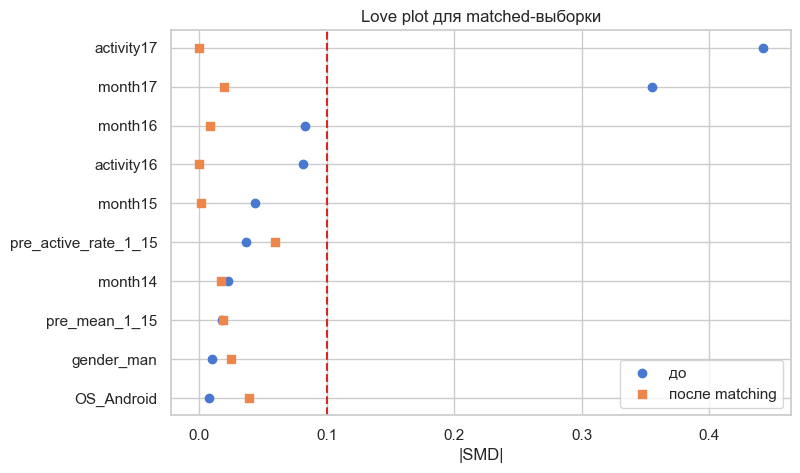

Максимальный |SMD| после matching: 0.060


In [15]:
match_balance = pd.DataFrame({
    'до': balance_features.apply(lambda x: smd_unweighted(x, T)).abs(),
    'после matching': balance_features.apply(
        lambda x: abs(
            (x.iloc[matched_t_positions].mean() - x.iloc[matched_c_positions].mean())
            / np.sqrt(
                (x.iloc[matched_t_positions].var(ddof=1)
                 + x.iloc[matched_c_positions].var(ddof=1)) / 2
            )
        )
    ),
}).sort_values('до')

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(match_balance['до'], match_balance.index, label='до', marker='o')
ax.scatter(match_balance['после matching'], match_balance.index, label='после matching', marker='s')
ax.axvline(.1, color='tab:red', ls='--')
ax.set(title='Love plot для matched-выборки', xlabel='|SMD|', ylabel='')
ax.legend()
plt.show()

print(f"Максимальный |SMD| после matching: {match_balance['после matching'].max():.3f}")

Matching оценивает ATT, а не ATE. Он служит проверкой устойчивости, но по-прежнему корректирует только наблюдаемые признаки и чувствителен к выбору модели propensity и caliper.

## 9. Placebo-проверки

Кнопка из `month18` не могла повлиять на предыдущие месяцы. Поэтому `month13`–`month17` используются как negative-control outcomes; для каждого месяца модели получают только более раннюю историю. Ненулевые placebo-оценки указывают на selection bias или остаточный confounding.

,month,estimate,low,high,pvalue
0,month13,-0.2,-37.8,37.4,0.9924
1,month14,-37.4,-75.7,0.8,0.0550
2,month15,-58.7,-95.6,-21.7,0.0019
3,month16,91.5,53.5,129.5,0.0000
4,month17,368.0,333.9,402.1,0.0000


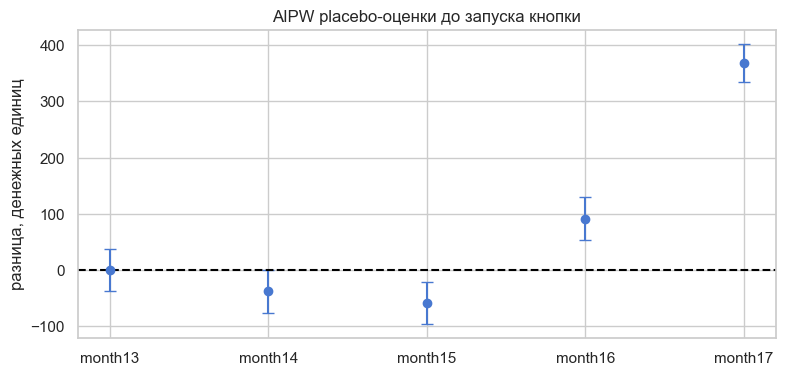

In [16]:
placebo_rows = []
for month_number in range(13, 18):
    placebo_y = df[f'month{month_number}'].to_numpy()
    placebo_X = make_feature_matrix(df, last_pre_month=month_number-1)
    p_e, p_m0, p_m1 = crossfit_nuisance(
        placebo_X,
        placebo_y,
        T,
        seed=RANDOM_STATE + month_number,
        max_iter=100,
    )
    placebo_ate, _, _ = aipw_ate_att(placebo_y, T, p_e, p_m0, p_m1)
    placebo_rows.append({
        'month': f'month{month_number}',
        'estimate': placebo_ate['estimate'],
        'low': placebo_ate['low'],
        'high': placebo_ate['high'],
        'pvalue': placebo_ate['pvalue'],
    })

placebo = pd.DataFrame(placebo_rows)
display(placebo.round({'estimate': 1, 'low': 1, 'high': 1, 'pvalue': 4}))

fig, ax = plt.subplots(figsize=(9, 4))
x_pos = np.arange(len(placebo))
ax.errorbar(
    x_pos,
    placebo['estimate'],
    yerr=[placebo['estimate']-placebo['low'], placebo['high']-placebo['estimate']],
    fmt='o',
    capsize=4,
)
ax.axhline(0, color='black', ls='--')
ax.set(xticks=x_pos, xticklabels=placebo['month'],
       title='AIPW placebo-оценки до запуска кнопки',
       ylabel='разница, денежных единиц', xlabel='')
plt.show()

В `month15`–`month17` появляются статистически значимые «эффекты» до запуска кнопки, особенно сильные в двух последних месяцах. Это подтверждает, что назначение связано с динамическим состоянием клиента, и ограничивает причинную интерпретацию даже гибких корректировок.

## 10. MDE будущего рандомизированного эксперимента

MDE относится только к **будущему корректно рандомизированному тесту**. Для CUPAC-варианта используется out-of-fold прогноз контрольного исхода, поэтому снижение дисперсии не является in-sample артефактом. Приняты `α=0.05`, power 80%, двусторонняя проверка.

In [17]:
control_mask = T == 0
raw_control_var = Y[control_mask].var(ddof=1)
oof_residual = Y - m0_hat
residual_control_var = oof_residual[control_mask].var(ddof=1)
variance_reduction = 1 - residual_control_var/raw_control_var

z_sum = stats.norm.ppf(1-ALPHA/2) + stats.norm.ppf(.80)

def mde_for_design(n_test, n_control, variance):
    return z_sum * np.sqrt(variance * (1/n_test + 1/n_control))

mde_raw_10_90 = mde_for_design(3_000, 27_000, raw_control_var)
mde_adj_10_90 = mde_for_design(3_000, 27_000, residual_control_var)
mde_adj_50_50 = mde_for_design(15_000, 15_000, residual_control_var)

mde_table = pd.DataFrame({
    'дизайн': ['10/90 без корректировки', '10/90 с OOF-CUPAC', '50/50 с OOF-CUPAC'],
    'MDE, абс.': [mde_raw_10_90, mde_adj_10_90, mde_adj_50_50],
})
mde_table['MDE, % от среднего контроля'] = mde_table['MDE, абс.'] / yc.mean() * 100

print(f'OOF-снижение дисперсии контроля: {variance_reduction:.1%}')
display(mde_table.round(2))

OOF-снижение дисперсии контроля: 26.6%


,дизайн,"MDE, абс.","MDE, % от среднего контроля"
0,10/90 без корректировки,61.43,6.36
1,10/90 с OOF-CUPAC,52.64,5.45
2,50/50 с OOF-CUPAC,31.58,3.27


При 3 000 клиентах в пилоте и 27 000 в контроле ожидаемый uplift 8–10% должен быть детектируем в корректном месячном RCT. Однако более равномерный split существенно эффективнее при том же общем размере выборки.

## 11. Сводка оценок

,method,estimand,estimate,low,high,relative,pvalue
0,Наивное сравнение,association,113.6,69.9,157.2,+11.8%,0.0000
1,Постстратификация activity17,ATE*,6.5,-36.8,49.8,+0.7%,0.7686
2,OLS + HC3,conditional association,3.0,-34.8,40.9,+0.3%,0.8757
3,Cross-fitted AIPW,ATE*,1.7,-38.2,41.6,+0.2%,0.9336
4,Matching без возвращения,ATT*,3.2,-51.2,57.5,+0.3%,0.9093
5,Cross-fitted AIPW,ATT*,12.2,-25.1,49.4,+1.1%,0.5213


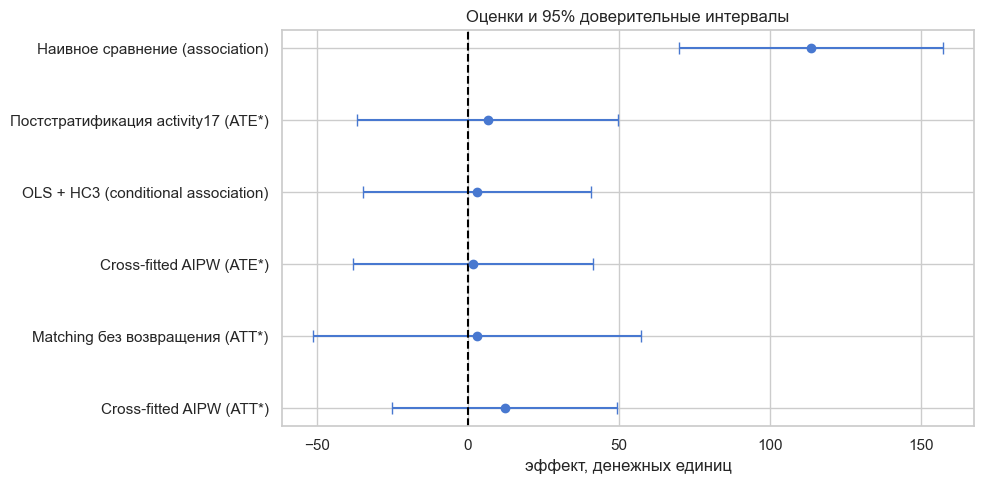

In [18]:
summary = pd.DataFrame([
    {'method': 'Наивное сравнение', 'estimand': 'association', **naive},
    {'method': 'Постстратификация activity17', 'estimand': 'ATE*', **post},
    {'method': 'OLS + HC3', 'estimand': 'conditional association', **ols_adjusted},
    {'method': 'Cross-fitted AIPW', 'estimand': 'ATE*', **aipw_ate},
    {'method': 'Matching без возвращения', 'estimand': 'ATT*', **matching_att},
    {'method': 'Cross-fitted AIPW', 'estimand': 'ATT*', **aipw_att},
])

display_table = summary[[
    'method', 'estimand', 'estimate', 'low', 'high', 'relative', 'pvalue'
]].copy()
display_table['relative'] = display_table['relative'].map(lambda x: f'{x:+.1%}')
display(display_table.round({'estimate': 1, 'low': 1, 'high': 1, 'pvalue': 4}))

fig, ax = plt.subplots(figsize=(10, 5))
plot_data = summary.iloc[::-1].reset_index(drop=True)
y_pos = np.arange(len(plot_data))
ax.errorbar(
    plot_data['estimate'],
    y_pos,
    xerr=[plot_data['estimate']-plot_data['low'], plot_data['high']-plot_data['estimate']],
    fmt='o',
    capsize=4,
)
ax.axvline(0, color='black', ls='--')
labels = plot_data['method'] + ' (' + plot_data['estimand'] + ')'
ax.set(yticks=y_pos, yticklabels=labels,
       title='Оценки и 95% доверительные интервалы',
       xlabel='эффект, денежных единиц', ylabel='')
plt.tight_layout()
plt.show()

`ATE*` и `ATT*` имеют причинную интерпретацию только при выполнении перечисленных допущений. Методы оценивают разные целевые эффекты, поэтому их близость — полезная sensitivity check, но не три независимых доказательства.

## 12. Решение и ограничения

### Ответ менеджеру

Прямое сравнение действительно показывает +11,8%, но группы были несопоставимы ещё до запуска: в `month17` пилот опережал контроль на 42,9%, а доля активных клиентов составляла 72,8% против 51,9%.

После поправки по наблюдаемой истории основной cross-fitted AIPW даёт ATE около **+0,2%** с 95% интервалом примерно от **−3,9% до +4,3%**. Ожидаемые +8–10% этими скорректированными данными не поддерживаются. Вместе с тем placebo-проверки обнаруживают selection bias до теста, поэтому нельзя утверждать, что истинный причинный эффект равен нулю.

**Рекомендация:** не раскатывать изменение на основании текущего анализа. Перезапустить эксперимент со случайным назначением, заранее зафиксировать primary metric и MDE, проверить SRM и баланс до чтения результата. Для механики кнопки добавить конверсию в оплату и время до оплаты; выручку и средний чек оставить основной/guardrail-метриками в зависимости от продуктовой цели.

### Ограничения

- назначение в пилот неслучайно;
- conditional exchangeability и отсутствие ненаблюдаемых конфаундеров непроверяемы;
- неизвестны фактическая экспозиция кнопки и compliance;
- отсутствуют сведения о других изменениях в `month18`;
- денежная единица и публичная лицензия учебного датасета не указаны;
- результаты относятся к одному месяцу и этой клиентской популяции.